# Day 10：收官之战 —— 从零搭建迷你 ResNet> 🌉 第八周 · ResNet 的深度 · 第 10 天这是阶段四的收官之日。过去九天，我们从退化问题出发，一路走到 ResNet 家族。今天，我们要把所有知识融会贯通，从零搭建一个完整的迷你 ResNet，并用它解决一个真实的分类问题。这不是练习——这是你第一次亲手打造一个"工业级"架构的缩影。**今天的任务**：1. 从零搭建完整的 MiniResNet（包含所有关键组件）2. 在真实数据上训练并评估3. 全面回顾这两周学到的核心知识---

## 1. 历史剧场：ResNet 的遗产2015 年 ResNet 的出现，不仅仅是一个新模型的诞生——它改变了深度学习的思维方式。**ResNet 之前**：人们认为"更深的网络 = 更好的网络"，但不知道怎么训练深层网络。**ResNet 之后**：人们意识到，关键不是"网络有多深"，而是"信息能否顺畅流动"。残差连接让信息有了"近道"，从此网络可以轻松堆到几百层。**ResNet 的思想遗产**：- **DenseNet**（2017）：每一层都和前面所有层有跳跃连接- **Highway Network**（2015）：残差连接的"前辈"，用门控机制控制信息流- **Transformer**（2017）：注意力机制中的残差连接——没错，Transformer 也用了残差！- **U-Net**（2015）：编码器-解码器之间的跳跃连接**残差连接已经成为深度学习的"基础设施"**——几乎所有现代架构都在用它。---

## 2. 生活隐喻：从零盖一栋楼今天我们要做的，就像从零盖一栋楼：1. **打地基**（Stem）：把原始输入转换到特征空间2. **盖楼层**（ResidualBlock）：一层一层堆叠残差块3. **加电梯**（跳跃连接）：让信息可以快速上下传递4. **封顶**（Head）：把特征映射到最终输出5. **验收**（评估）：检查楼是否盖好了---

<p align="center">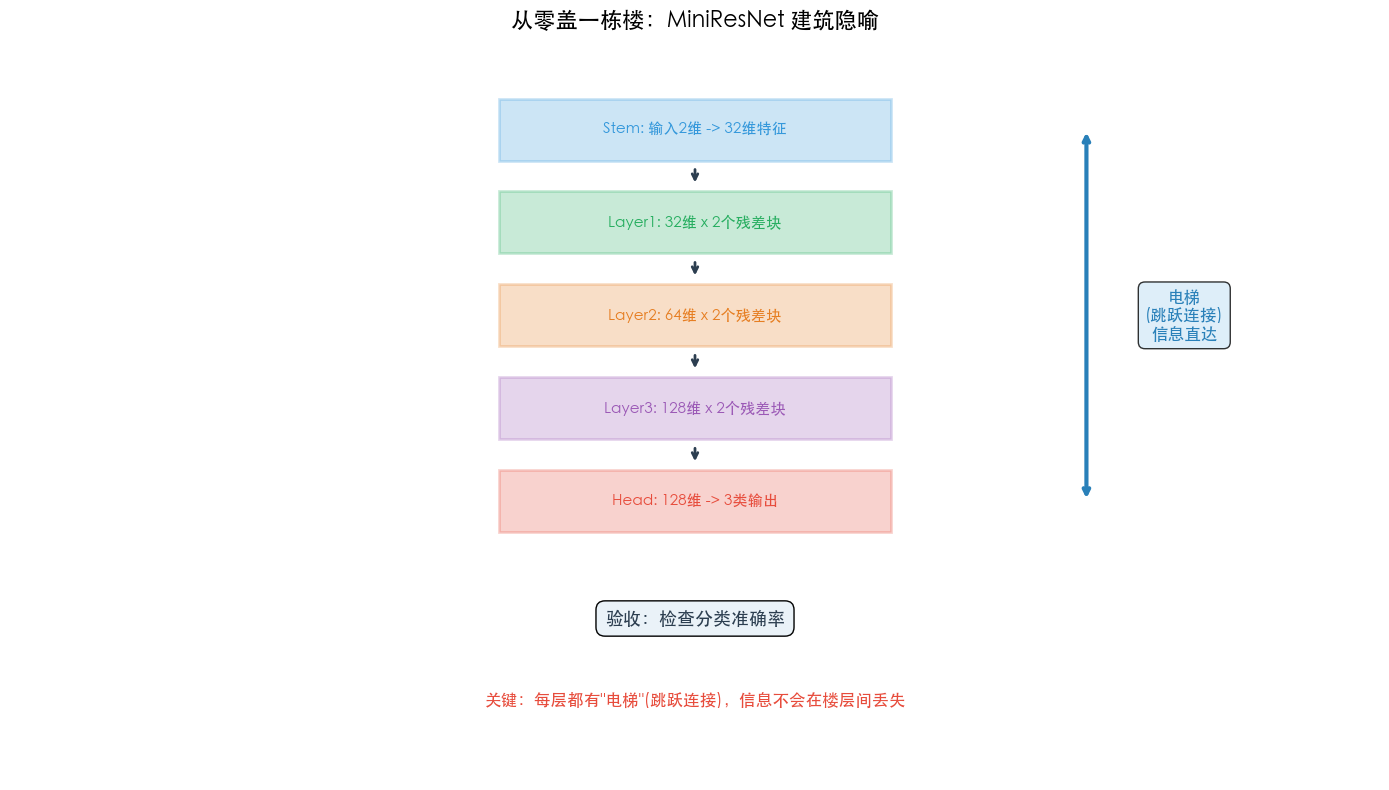</p>*盖楼隐喻示意图*

## 3. 代码实验室：从零搭建 MiniResNet### 3.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.2 零件一：残差块

In [ ]:
class ResidualBlock(nn.Module):    """标准残差块：两层变换 + 跳跃连接"""    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        out = out + identity        out = F.relu(out)        return out

### 3.3 零件二：投影残差块（维度变化时使用）

In [ ]:
class ProjectionResidualBlock(nn.Module):    """带投影的残差块：当输入输出维度不同时使用"""    def __init__(self, in_size, out_size):        super().__init__()        self.layer1 = nn.Linear(in_size, out_size)        self.bn1 = nn.BatchNorm1d(out_size)        self.layer2 = nn.Linear(out_size, out_size)        self.bn2 = nn.BatchNorm1d(out_size)        self.projection = nn.Linear(in_size, out_size)    def forward(self, x):        identity = self.projection(x)        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        out = out + identity        out = F.relu(out)        return out

### 3.4 零件三：Bottleneck 残差块

In [ ]:
class BottleneckBlock(nn.Module):    """Bottleneck 残差块：先压缩再加工再恢复"""    def __init__(self, hidden_size, reduction=4):        super().__init__()        narrow_size = hidden_size // reduction        self.compress = nn.Linear(hidden_size, narrow_size)        self.bn1 = nn.BatchNorm1d(narrow_size)        self.process = nn.Linear(narrow_size, narrow_size)        self.bn2 = nn.BatchNorm1d(narrow_size)        self.expand = nn.Linear(narrow_size, hidden_size)        self.bn3 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.compress(x)))        out = F.relu(self.bn2(self.process(out)))        out = self.bn3(self.expand(out))        out = out + identity        out = F.relu(out)        return out

### 3.5 组装：MiniResNet

In [ ]:
class MiniResNet(nn.Module):    """    迷你 ResNet：从零搭建的完整架构    架构设计：    - Stem: 输入 → 隐藏层    - Layer1: 若干残差块（通道数 = base_channels）    - Layer2: 投影块 + 若干残差块（通道数 = base_channels * 2）    - Layer3: 投影块 + 若干残差块（通道数 = base_channels * 4）    - Head: 隐藏层 → 输出    """    def __init__(self, input_size=2, num_classes=1,                 base_channels=32, blocks_per_layer=[2, 2, 2],                 block_type='basic'):        super().__init__()        self.stem = nn.Sequential(            nn.Linear(input_size, base_channels),            nn.BatchNorm1d(base_channels),            nn.ReLU(),        )        self.layer1 = self._make_layer(base_channels, base_channels,                                        blocks_per_layer[0], block_type)        self.layer2 = self._make_layer(base_channels, base_channels * 2,                                        blocks_per_layer[1], block_type)        self.layer3 = self._make_layer(base_channels * 2, base_channels * 4,                                        blocks_per_layer[2], block_type)        self.head = nn.Sequential(            nn.Linear(base_channels * 4, num_classes),            nn.Sigmoid(),        )    def _make_layer(self, in_channels, out_channels, num_blocks, block_type):        """构建一个残差层组"""        layers = []        if in_channels != out_channels:            layers.append(ProjectionResidualBlock(in_channels, out_channels))        else:            if block_type == 'bottleneck':                layers.append(BottleneckBlock(out_channels))            else:                layers.append(ResidualBlock(out_channels))        for _ in range(num_blocks - 1):            if block_type == 'bottleneck':                layers.append(BottleneckBlock(out_channels))            else:                layers.append(ResidualBlock(out_channels))        return nn.Sequential(*layers)    def forward(self, x):        x = self.stem(x)        x = self.layer1(x)        x = self.layer2(x)        x = self.layer3(x)        x = self.head(x)        return x

---

## 4. 训练与评估### 4.1 数据：三类别螺旋

In [ ]:
def make_multi_spiral_data(n_samples=600, n_classes=3, noise=0.3):    np.random.seed(42)    n = n_samples // n_classes    X_list, y_list = [], []    for class_idx in range(n_classes):        theta = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise        r = theta / (2 * np.pi) + np.random.randn(n) * noise * 0.3        offset = 2 * np.pi * class_idx / n_classes        x1 = r * np.cos(theta + offset)        x2 = r * np.sin(theta + offset)        X_list.append(np.column_stack([x1, x2]))        y_list.append(np.full(n, class_idx))    X = np.vstack(X_list).astype(np.float32)    y = np.concatenate(y_list).astype(np.int64)    return torch.tensor(X), torch.tensor(y)

### 4.2 修改 MiniResNet 以支持多分类

In [ ]:
class MiniResNetClassifier(nn.Module):    """支持多分类的 MiniResNet"""    def __init__(self, input_size=2, num_classes=3,                 base_channels=32, blocks_per_layer=[2, 2, 2]):        super().__init__()        self.stem = nn.Sequential(            nn.Linear(input_size, base_channels),            nn.BatchNorm1d(base_channels),            nn.ReLU(),        )        self.layer1 = self._make_layer(base_channels, base_channels, blocks_per_layer[0])        self.layer2 = self._make_layer(base_channels, base_channels * 2, blocks_per_layer[1])        self.layer3 = self._make_layer(base_channels * 2, base_channels * 4, blocks_per_layer[2])        self.head = nn.Linear(base_channels * 4, num_classes)    def _make_layer(self, in_ch, out_ch, num_blocks):        layers = []        if in_ch != out_ch:            layers.append(ProjectionResidualBlock(in_ch, out_ch))        else:            layers.append(ResidualBlock(out_ch))        for _ in range(num_blocks - 1):            layers.append(ResidualBlock(out_ch))        return nn.Sequential(*layers)    def forward(self, x):        x = self.stem(x)        x = self.layer1(x)        x = self.layer2(x)        x = self.layer3(x)        x = self.head(x)        return x

### 4.3 训练

In [ ]:
X_data, y_data = make_multi_spiral_data()torch.manual_seed(42)model = MiniResNetClassifier(    input_size=2,    num_classes=3,    base_channels=32,    blocks_per_layer=[2, 2, 2],)total_params = sum(p.numel() for p in model.parameters())print(f"MiniResNet 参数量: {total_params:,}")optimizer = torch.optim.Adam(model.parameters(), lr=0.005)loss_fn = nn.CrossEntropyLoss()losses = []accuracies = []epochs = 500for epoch in range(epochs):    logits = model(X_data)    loss = loss_fn(logits, y_data)    predicted_class = logits.argmax(dim=1)    accuracy = (predicted_class == y_data).float().mean()    optimizer.zero_grad()    loss.backward()    optimizer.step()    losses.append(loss.item())    accuracies.append(accuracy.item())    if (epoch + 1) % 100 == 0:        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {accuracy.item():.4f}")

### 4.4 结果可视化

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))axes[0].plot(losses, color='#3498db', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Loss', fontsize=12)axes[0].set_title('MiniResNet 训练损失', fontsize=14)axes[0].grid(True, alpha=0.3)axes[1].plot(accuracies, color='#2ecc71', alpha=0.8)axes[1].set_xlabel('Epoch', fontsize=12)axes[1].set_ylabel('Accuracy', fontsize=12)axes[1].set_title('MiniResNet 训练准确率', fontsize=14)axes[1].grid(True, alpha=0.3)h = 0.02x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)Z = model(grid).argmax(dim=1).detach().numpy().reshape(xx.shape)cmap = plt.cm.Set1axes[2].contourf(xx, yy, Z, alpha=0.3, levels=np.arange(-0.5, 3.5, 1), cmap=cmap)colors = ['#e74c3c', '#2ecc71', '#3498db']markers = ['x', 'o', 's']for cls in range(3):    mask = y_data == cls    axes[2].scatter(X_data[mask, 0], X_data[mask, 1],                    c=colors[cls], marker=markers[cls], s=20, alpha=0.6,                    label=f'类别 {cls}')axes[2].set_title('MiniResNet 决策边界', fontsize=14)axes[2].legend(fontsize=10)axes[2].set_aspect('equal')plt.tight_layout()plt.show()

---

## 5. 阶段四全回顾### 5.1 知识图谱

<p align="center">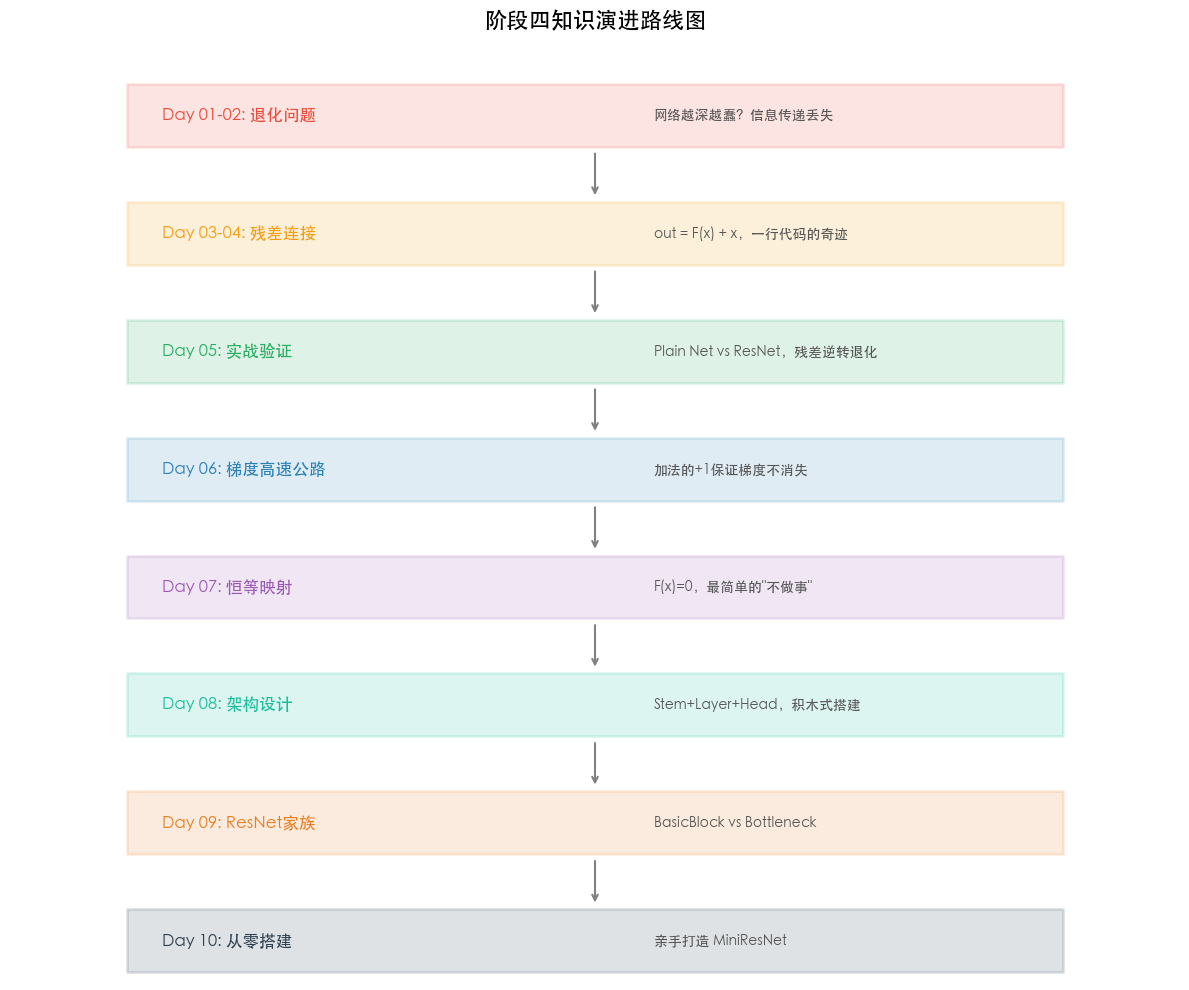</p>*阶段四知识路线图*

In [ ]:
print("""╔══════════════════════════════════════════════════════════════╗║              阶段四：ResNet 的奇迹 —— 知识图谱              ║╠══════════════════════════════════════════════════════════════╣║                                                              ║║  退化问题 (Day 01-02)                                        ║║  ├── 网络越深，训练误差反而越高                               ║║  ├── 不是过拟合，而是信息在传递中丢失                          ║║  └── BatchNorm 无法根治                                      ║║           ↓                                                  ║║  残差连接 (Day 03-04)                                        ║║  ├── 核心思想：学 F(x) 而不是 H(x)                           ║║  ├── 输出 = F(x) + x（一行代码的奇迹）                        ║║  └── F(x) = 0 等价于恒等映射                                 ║║           ↓                                                  ║║  实战验证 (Day 05)                                           ║║  ├── Plain Net vs ResNet：残差曲线逆转退化曲线                 ║║  └── 深度越大，ResNet 优势越明显                              ║║           ↓                                                  ║║  深度理解 (Day 06-07)                                        ║║  ├── 梯度高速公路：加法的导数 +1 保证梯度不消失               ║║  └── 恒等映射：F(x)=0 是最简单的"不做事"方式                 ║║           ↓                                                  ║║  架构设计 (Day 08-09)                                        ║║  ├── Stem + Layer + Head 的模块化设计                         ║║  ├── 投影块：维度变化时的适配器                               ║║  ├── BasicBlock vs Bottleneck                                ║║  └── ResNet-18 到 ResNet-152 的家族谱系                      ║║           ↓                                                  ║║  从零搭建 (Day 10)                                           ║║  └── 手写完整 MiniResNet，解决真实分类问题                     ║║                                                              ║╚══════════════════════════════════════════════════════════════╝""")

### 5.2 核心公式回顾

In [ ]:
print("ResNet 核心公式：\n")print("1. 残差块的前向传播：")print("   out = F(x) + x")print("   其中 F(x) 是两层（或三层）变换学到的残差\n")print("2. 残差块的梯度传播：")print("   ∂(F(x)+x)/∂x = F'(x) + 1")print("   加法的 +1 保证了梯度至少以原始大小传播\n")print("3. 恒等映射条件：")print("   当 F(x) = 0 时，out = x")print("   深层网络至少不差于浅层网络\n")print("4. Bottleneck 结构：")print("   输入 → [1×1 压缩] → [3×3 加工] → [1×1 恢复] + 输入")print("   在低维空间做变换，省参数")

---

## 今日结语恭喜你完成了阶段四的全部课程！在这两周里，你：1. **见证了退化问题**——网络越深反而越蠢2. **理解了残差连接的直觉**——学修正而不是学全部3. **手写了 ResidualBlock**——`out = F(x) + x` 一行代码的奇迹4. **看到了史诗对决**——Plain Net vs ResNet5. **理解了梯度高速公路**——加法的 +1 保证梯度不消失6. **领悟了恒等映射的优雅**——F(x) = 0 是最简单的"不做事"7. **学会了架构设计**——从块到网络的堆叠艺术8. **认识了 ResNet 家族**——从 ResNet-18 到 ResNet-1529. **从零搭建了 MiniResNet**——亲手打造了一个完整的深度网络**最重要的收获**：最伟大的创新，往往来自最简单的想法。何恺明用一行 `out = F(x) + x`，解决了困扰深度学习界多年的退化问题，让网络可以堆到 152 层甚至更深。下一个阶段，我们将进入全新的领域——**记忆的诞生**。当网络需要理解上下文、处理序列数据时，残差连接就不够了。我们需要赋予机器"记忆"——这就是 RNN 和 LSTM 的故事。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 从零盖一栋楼 | 从零搭建 MiniResNet || 打地基 | Stem：输入特征提取头 || 盖楼层 | 残差块堆叠 || 加电梯 | 跳跃连接/残差连接 || 封顶 | Head：输出映射层 || 验收 | 模型评估 || 退化问题 → 残差连接 → 梯度高速 → 恒等映射 → 架构设计 → 从零搭建 | 阶段四的知识演进路线 || 一行代码改变世界 | out = F(x) + x || 最伟大的创新来自最简单的想法 | ResNet 的哲学 || 下一步：赋予机器"记忆" | RNN/LSTM（阶段五预告） |